# Feature V3 Profiles

This notebook inspects the new `feature_added_v3` datasets:

- `KuaiRecLargeStrictPosV2_0.2`
- `lastfm0.03`

Focus:

1. workload / structure
2. tail-cap workload (`10` as default, `30/50` as side info)
3. macro context availability
4. stage-family intensity
5. selected feature distributions
6. light `v2` vs `v3` sanity-check


In [13]:
from __future__ import annotations

import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

REPO_ROOT = Path("/workspace/jy1559/FMoE")
TOOL_PATH = REPO_ROOT / "experiments/tools/analyze_feature_v3_profiles.py"
V3_ROOT = REPO_ROOT / "Datasets/processed/feature_added_v3"
V2_ROOT = REPO_ROOT / "Datasets/processed/feature_added_v2"
DATASETS = ["KuaiRecLargeStrictPosV2_0.2", "lastfm0.03"]
TAIL_CAPS = [10, 30, 50]

spec = importlib.util.spec_from_file_location("feature_v3_tool", TOOL_PATH)
tool = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(tool)


In [14]:
results = {
    dataset: tool.analyze_dataset(V3_ROOT, V2_ROOT, dataset)
    for dataset in DATASETS
}

structure_df = pd.DataFrame({k: v["structure"] for k, v in results.items()}).T
macro_df = pd.DataFrame({
    dataset: {
        "mac5_mean": res["macro_context"]["mac5_ctx_valid_r"]["mean"],
        "mac5_p90": res["macro_context"]["mac5_ctx_valid_r"]["p90"],
        "mac10_mean": res["macro_context"]["mac10_ctx_valid_r"]["mean"],
        "mac10_p90": res["macro_context"]["mac10_ctx_valid_r"]["p90"],
    }
    for dataset, res in results.items()
}).T

display(Markdown("## Structure"))
display(
    structure_df[
        [
            "rows",
            "sessions",
            "users",
            "items",
            "avg_session_len",
            "p90_session_len",
            "effective_tokens@10",
            "effective_tokens@30",
            "avg_sessions_per_user",
            "top10_item_share",
            "top100_item_share",
        ]
    ].style.format(
        {
            "rows": "{:,.0f}",
            "sessions": "{:,.0f}",
            "users": "{:,.0f}",
            "items": "{:,.0f}",
            "avg_session_len": "{:.2f}",
            "p90_session_len": "{:.1f}",
            "effective_tokens@10": "{:,.0f}",
            "effective_tokens@30": "{:,.0f}",
            "avg_sessions_per_user": "{:.2f}",
            "top10_item_share": "{:.3f}",
            "top100_item_share": "{:.3f}",
        }
    )
)


## Structure

,rows,sessions,users,items,avg_session_len,p90_session_len,effective_tokens@10,effective_tokens@30,avg_sessions_per_user,top10_item_share,top100_item_share
KuaiRecLargeStrictPosV2_0.2,"287,411","24,458","1,122","6,477",11.75,24.0,"188,726","263,313",21.80,0.024,0.117
lastfm0.03,"470,408","25,089",130,"52,510",18.75,44.0,"223,542","405,183",192.99,0.005,0.026


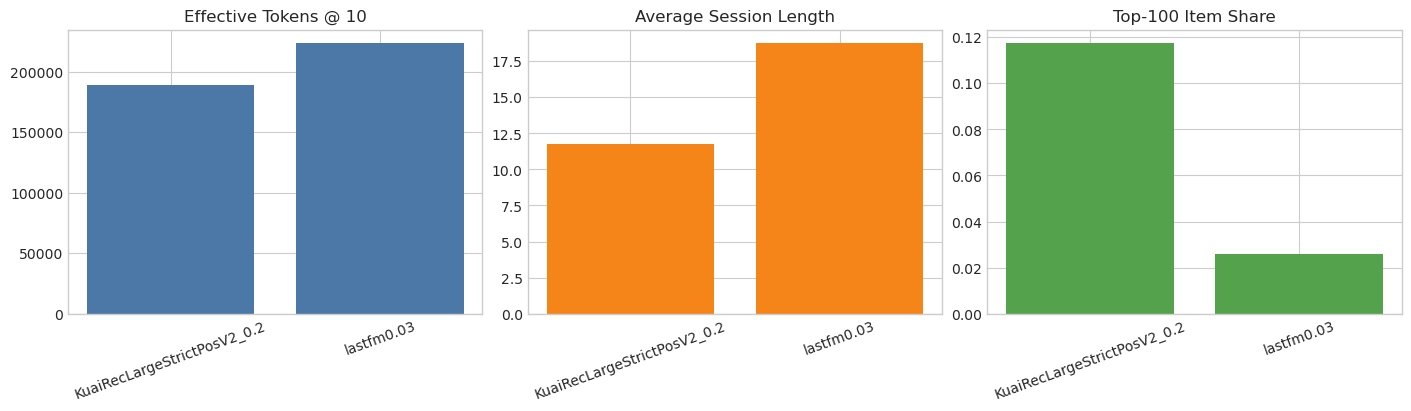

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
order = structure_df["effective_tokens@10"].sort_values().index.tolist()
plot_df = structure_df.loc[order]

axes[0].bar(plot_df.index, plot_df["effective_tokens@10"], color="#4C78A8")
axes[0].set_title("Effective Tokens @ 10")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(plot_df.index, plot_df["avg_session_len"], color="#F58518")
axes[1].set_title("Average Session Length")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(plot_df.index, plot_df["top100_item_share"], color="#54A24B")
axes[2].set_title("Top-100 Item Share")
axes[2].tick_params(axis="x", rotation=20)

plt.show()


## Tail Cap View

This section treats **tail `10`** as the default training view.

- `tail 10`: main operating point
- `tail 30`: extra context / safer comparison point
- `tail 50`: near-full reference for these datasets

Front prefixes are **discarded**, not split into additional sessions.


In [16]:
tail_features = [
    "mid_valid_r",
    "mid_novel_r",
    "mid_pop_mean",
    "mic_valid_r",
    "mic_is_recons",
    "mic_pop_delta_vs_mid",
]

tail_cap_rows = []
tail_feature_delta_rows = []

for dataset in DATASETS:
    df = tool.load_feature_df(tool.resolve_inter_path(V3_ROOT, dataset), tail_features)
    sess_size = df.groupby("session_id", sort=False).size()
    full_rows = len(df)
    per_cap = {}

    for cap in TAIL_CAPS:
        tail = df.groupby("session_id", sort=False, group_keys=False).tail(cap)
        kept_sess = tail.groupby("session_id", sort=False).size()
        per_cap[cap] = {
            "rows": int(len(tail)),
            "kept_ratio": float(len(tail) / full_rows),
            "dropped_rows": int(full_rows - len(tail)),
            "avg_kept_len": float(kept_sess.mean()),
            "p90_kept_len": float(kept_sess.quantile(0.9)),
            "unaffected_session_ratio": float((sess_size <= cap).mean()),
        }
        for feat in tail_features:
            per_cap[cap][feat] = float(pd.to_numeric(tail[feat], errors="coerce").mean())

    base = per_cap[10]
    for cap in TAIL_CAPS:
        row = {"dataset": dataset, "cap": cap}
        row.update(per_cap[cap])
        tail_cap_rows.append(row)
        if cap == 10:
            continue
        delta_row = {"dataset": dataset, "cap": cap}
        for feat in tail_features:
            delta_row[feat + "_delta_vs10"] = per_cap[cap][feat] - base[feat]
        tail_feature_delta_rows.append(delta_row)

tail_cap_df = pd.DataFrame(tail_cap_rows).set_index(["dataset", "cap"]).sort_index()
tail_delta_df = pd.DataFrame(tail_feature_delta_rows).set_index(["dataset", "cap"]).sort_index()

display(Markdown("### Tail Cap Workload"))
display(
    tail_cap_df[
        ["rows", "kept_ratio", "dropped_rows", "avg_kept_len", "p90_kept_len", "unaffected_session_ratio"]
    ].style.format(
        {
            "rows": "{:,.0f}",
            "kept_ratio": "{:.3f}",
            "dropped_rows": "{:,.0f}",
            "avg_kept_len": "{:.2f}",
            "p90_kept_len": "{:.1f}",
            "unaffected_session_ratio": "{:.3f}",
        }
    )
)

display(Markdown("### Feature Shift vs Tail 10"))
display(tail_delta_df.style.format("{:+.3f}"))


### Tail Cap Workload

### Feature Shift vs Tail 10

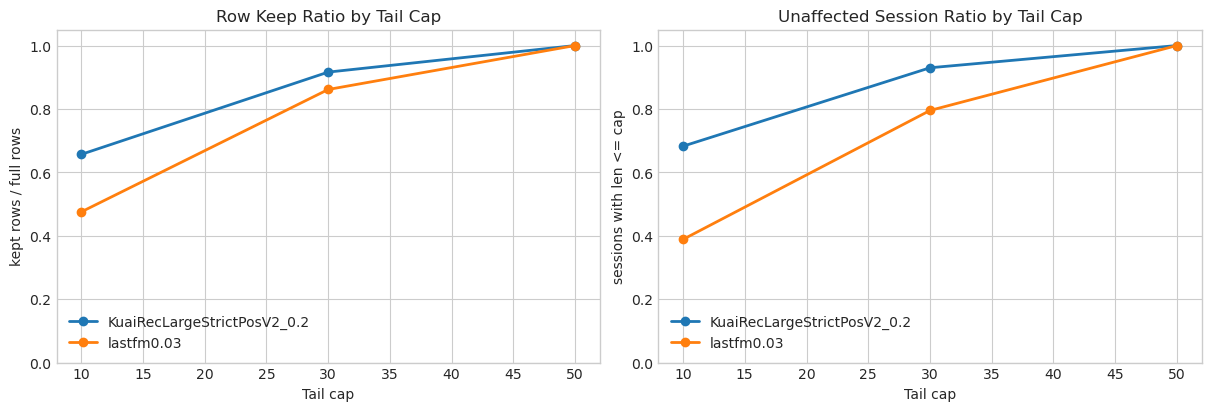

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for dataset in DATASETS:
    sub = tail_cap_df.loc[dataset]
    axes[0].plot(sub.index, sub["kept_ratio"], marker="o", linewidth=2, label=dataset)
    axes[1].plot(sub.index, sub["unaffected_session_ratio"], marker="o", linewidth=2, label=dataset)

axes[0].set_title("Row Keep Ratio by Tail Cap")
axes[0].set_xlabel("Tail cap")
axes[0].set_ylabel("kept rows / full rows")
axes[0].set_ylim(0.0, 1.05)

axes[1].set_title("Unaffected Session Ratio by Tail Cap")
axes[1].set_xlabel("Tail cap")
axes[1].set_ylabel("sessions with len <= cap")
axes[1].set_ylim(0.0, 1.05)

for ax in axes:
    ax.legend()

plt.show()


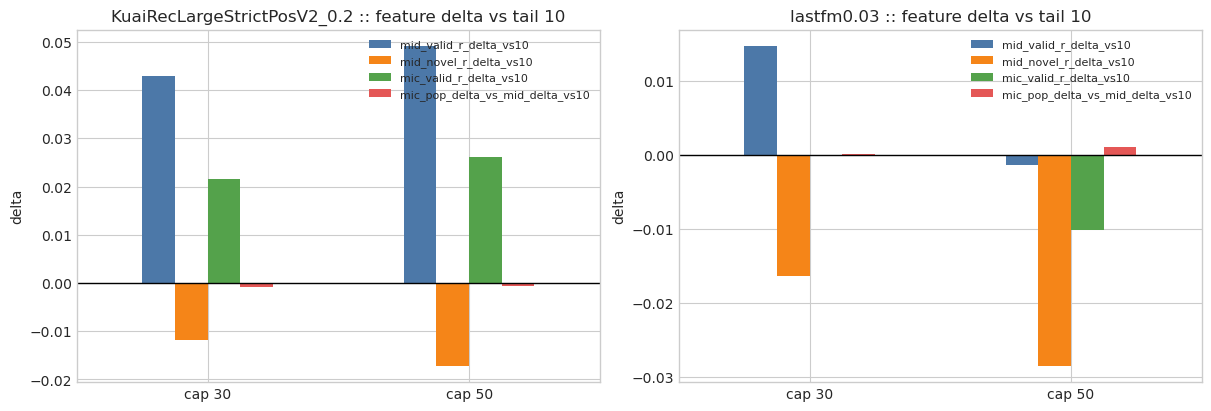

In [18]:
delta_plot_features = [
    "mid_valid_r_delta_vs10",
    "mid_novel_r_delta_vs10",
    "mic_valid_r_delta_vs10",
    "mic_pop_delta_vs_mid_delta_vs10",
]

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4), constrained_layout=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    sub = tail_delta_df.loc[dataset]
    plot = sub[delta_plot_features].copy()
    plot.index = [f"cap {idx}" for idx in plot.index]
    plot.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_title(f"{dataset} :: feature delta vs tail 10")
    ax.set_ylabel("delta")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="best", fontsize=8)

plt.show()


## Macro Context Availability

,mac5_mean,mac5_p90,mac10_mean,mac10_p90
KuaiRecLargeStrictPosV2_0.2,0.908,1.000,0.824,1.000
lastfm0.03,0.985,1.000,0.973,1.000


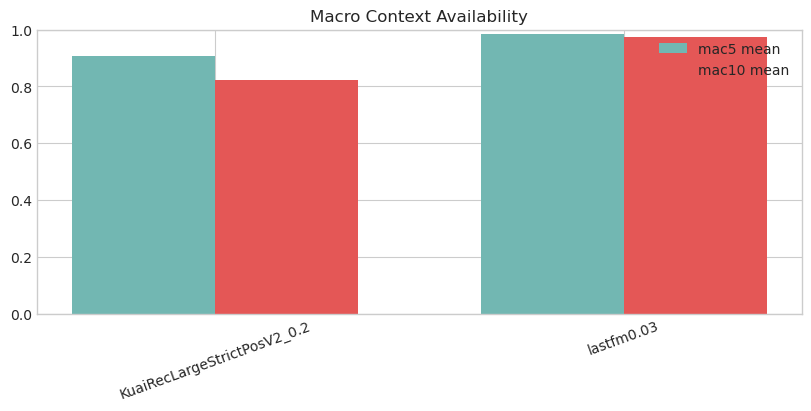

In [19]:
display(Markdown("## Macro Context Availability"))
display(macro_df.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
x = np.arange(len(macro_df.index))
width = 0.35
ax.bar(x - width / 2, macro_df["mac5_mean"], width, label="mac5 mean", color="#72B7B2")
ax.bar(x + width / 2, macro_df["mac10_mean"], width, label="mac10 mean", color="#E45756")
ax.set_xticks(x)
ax.set_xticklabels(macro_df.index, rotation=20)
ax.set_ylim(0.0, 1.0)
ax.set_title("Macro Context Availability")
ax.legend()
plt.show()


## Stage / Family Mean Intensity

,macro5.Tempo,macro5.Focus,macro5.Memory,macro5.Exposure,macro10.Tempo,macro10.Focus,macro10.Memory,macro10.Exposure,mid.Tempo,mid.Focus,mid.Memory,mid.Exposure,micro.Tempo,micro.Focus,micro.Memory,micro.Exposure
KuaiRecLargeStrictPosV2_0.2,0.613,0.627,0.239,0.663,0.587,0.618,0.237,0.676,0.546,0.596,0.498,0.590,0.573,0.676,0.342,0.585
lastfm0.03,0.631,0.600,0.282,0.623,0.627,0.587,0.282,0.626,0.580,0.441,0.349,0.578,0.580,0.364,0.347,0.562


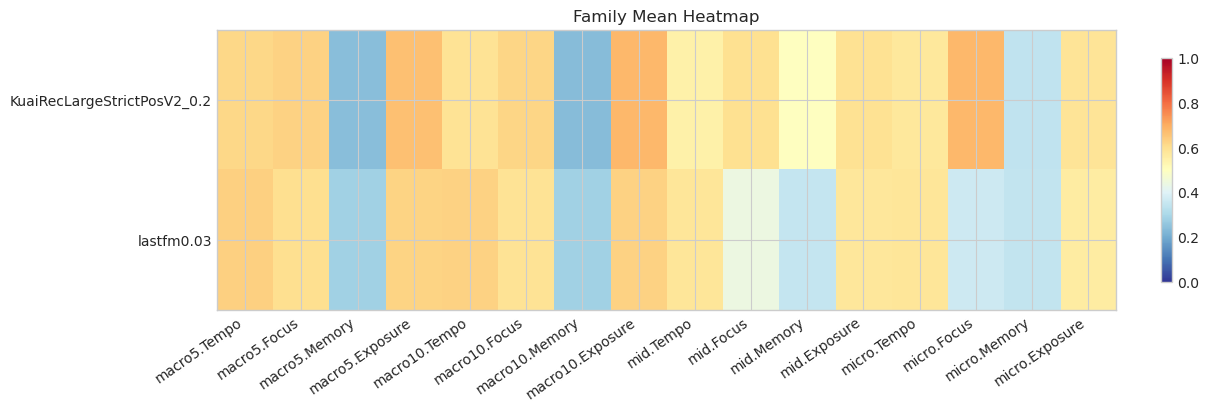

In [20]:
family_rows = {}
for dataset, res in results.items():
    row = {}
    for stage, family_map in res["family_means"].items():
        for family, mean_value in family_map.items():
            row[f"{stage}.{family}"] = mean_value
    family_rows[dataset] = row

family_df = pd.DataFrame(family_rows).T
display(Markdown("## Stage / Family Mean Intensity"))
display(family_df.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
im = ax.imshow(family_df.to_numpy(), cmap="RdYlBu_r", aspect="auto", vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(len(family_df.columns)))
ax.set_xticklabels(family_df.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(family_df.index)))
ax.set_yticklabels(family_df.index)
ax.set_title("Family Mean Heatmap")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()


In [21]:
selected_features = [
    "mac5_ctx_valid_r",
    "mac10_ctx_valid_r",
    "mid_valid_r",
    "mid_novel_r",
    "mid_pop_mean",
    "mic_valid_r",
    "mic_is_recons",
    "mic_pop_delta_vs_mid",
]

def load_selected_feature_frame(dataset: str, features: list[str]) -> pd.DataFrame:
    meta = tool.load_meta(tool.resolve_meta_path(V3_ROOT, dataset, version="v3"))
    return tool.load_feature_df(tool.resolve_inter_path(V3_ROOT, dataset), [f for f in features if f in meta["all_features"]])

feature_frames = {dataset: load_selected_feature_frame(dataset, selected_features) for dataset in DATASETS}
summary_rows = {}
for dataset, df in feature_frames.items():
    summary_rows[dataset] = {
        feat: float(pd.to_numeric(df[feat], errors="coerce").mean())
        for feat in selected_features if feat in df.columns
    }

selected_df = pd.DataFrame(summary_rows).T
display(Markdown("## Selected Feature Means"))
display(selected_df.style.format("{:.3f}"))


## Selected Feature Means

,mac5_ctx_valid_r,mac10_ctx_valid_r,mid_valid_r,mid_novel_r,mid_pop_mean,mic_valid_r,mic_is_recons,mic_pop_delta_vs_mid
KuaiRecLargeStrictPosV2_0.2,0.908,0.824,0.582,0.804,0.558,0.745,0.098,0.495
lastfm0.03,0.985,0.973,0.721,0.259,0.553,0.840,0.102,0.488


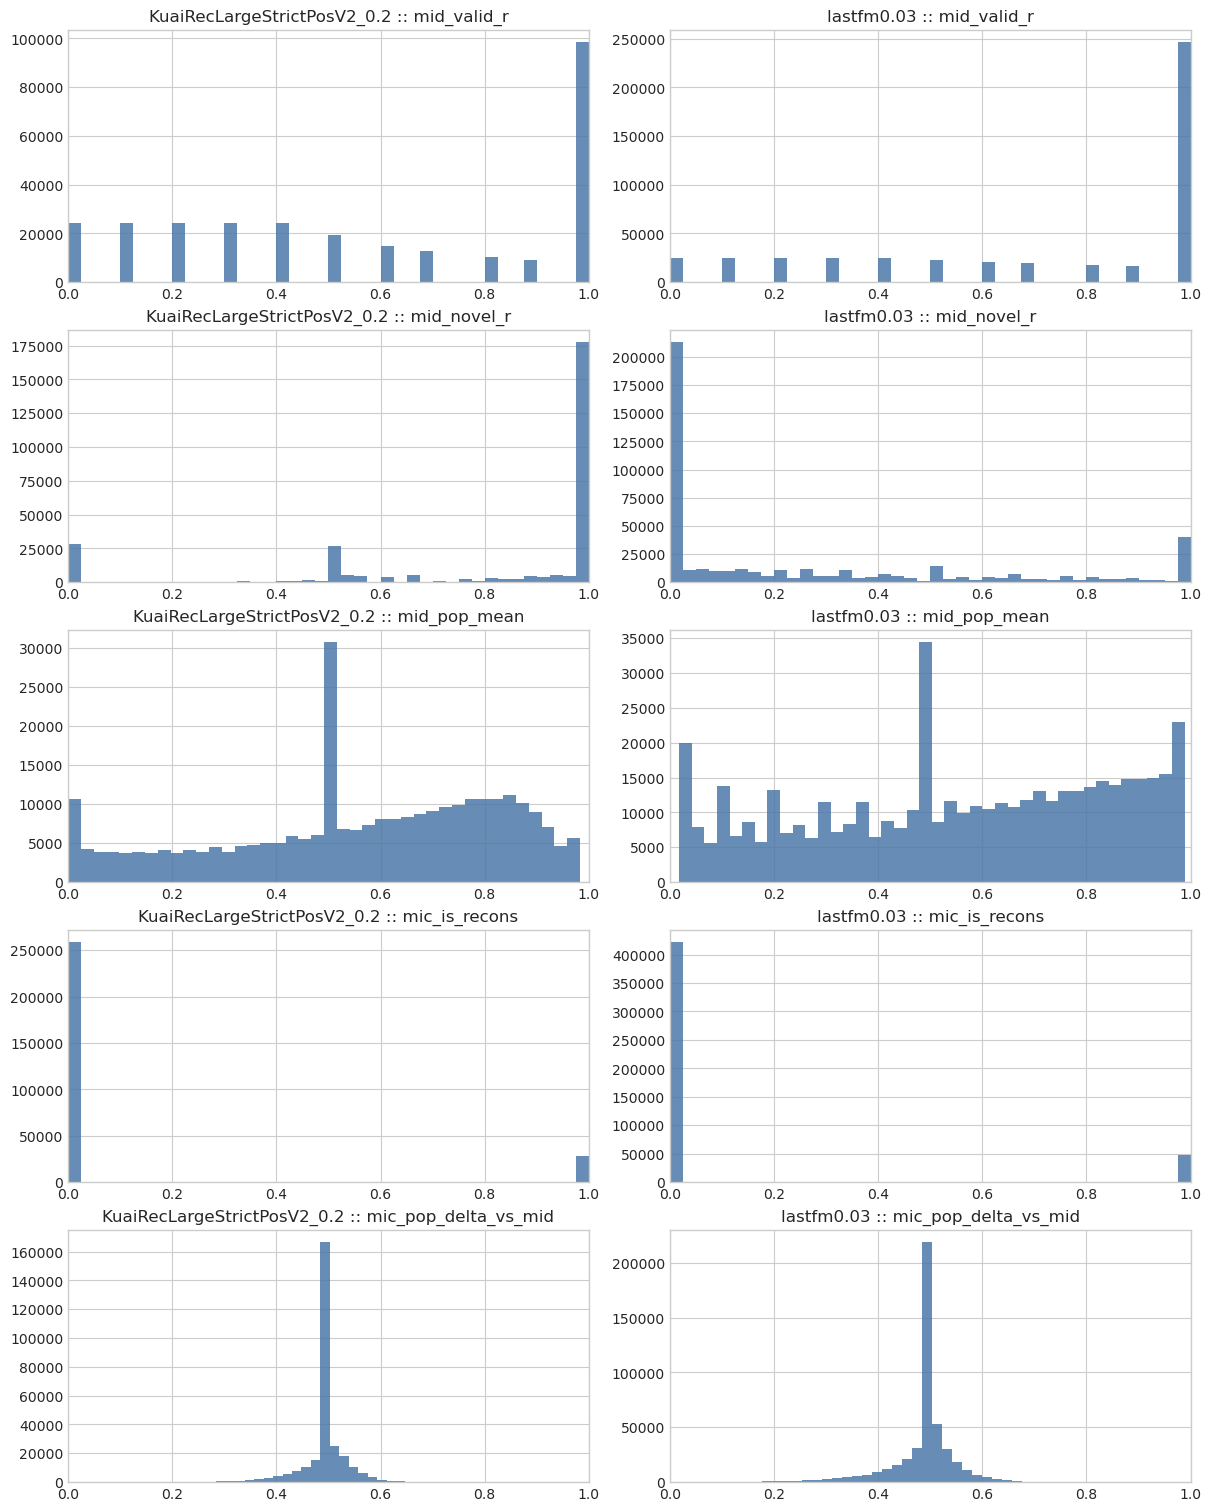

In [22]:
plot_features = [
    "mid_valid_r",
    "mid_novel_r",
    "mid_pop_mean",
    "mic_is_recons",
    "mic_pop_delta_vs_mid",
]

fig, axes = plt.subplots(len(plot_features), len(DATASETS), figsize=(12, 3 * len(plot_features)), constrained_layout=True)
if len(plot_features) == 1:
    axes = np.array([axes])

for row_idx, feature in enumerate(plot_features):
    for col_idx, dataset in enumerate(DATASETS):
        ax = axes[row_idx, col_idx]
        df = feature_frames[dataset]
        vals = pd.to_numeric(df[feature], errors="coerce").dropna().to_numpy(dtype=np.float64)
        ax.hist(vals, bins=40, color="#4C78A8", alpha=0.85)
        ax.set_xlim(0.0, 1.0)
        ax.set_title(f"{dataset} :: {feature}")

plt.show()


In [23]:
display(Markdown("## Light V2 vs V3 Compare"))
compare_frames = []
for dataset, res in results.items():
    if not res["v2_overlap"]:
        continue
    df = pd.DataFrame(res["v2_overlap"]).T
    df.insert(0, "dataset", dataset)
    compare_frames.append(df.reset_index().rename(columns={"index": "feature"}))

if compare_frames:
    compare_df = pd.concat(compare_frames, ignore_index=True)
    display(compare_df.style.format({"v2_mean": "{:.3f}", "v3_mean": "{:.3f}", "v2_p90": "{:.3f}", "v3_p90": "{:.3f}"}))
else:
    display(Markdown("_No overlapping features found for a light v2 compare._"))


## Light V2 vs V3 Compare

,feature,dataset,v2_mean,v3_mean,v2_p90,v3_p90
0,mid_valid_r,KuaiRecLargeStrictPosV2_0.2,0.582,0.582,1.000,1.000
1,mid_int_std,KuaiRecLargeStrictPosV2_0.2,-0.085,0.538,1.090,0.788
2,mid_novel_r,KuaiRecLargeStrictPosV2_0.2,0.803,0.804,1.000,1.000
3,mic_valid_r,KuaiRecLargeStrictPosV2_0.2,0.830,0.745,1.000,1.000
4,mic_is_recons,KuaiRecLargeStrictPosV2_0.2,0.098,0.098,0.000,0.000
5,mid_valid_r,lastfm0.03,0.721,0.721,1.000,1.000
6,mid_int_std,lastfm0.03,0.043,0.550,1.559,0.729
7,mid_novel_r,lastfm0.03,0.257,0.259,0.900,0.895
8,mic_valid_r,lastfm0.03,0.893,0.840,1.000,1.000
9,mic_is_recons,lastfm0.03,0.102,0.102,1.000,1.000


In [24]:
def plot_feature_hist(feature_name: str, bins: int = 50) -> None:
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 4), constrained_layout=True)
    if len(DATASETS) == 1:
        axes = [axes]
    for ax, dataset in zip(axes, DATASETS):
        meta = tool.load_meta(tool.resolve_meta_path(V3_ROOT, dataset, version="v3"))
        if feature_name not in meta["all_features"]:
            ax.set_title(f"{dataset}: missing {feature_name}")
            ax.axis("off")
            continue
        df = tool.load_feature_df(tool.resolve_inter_path(V3_ROOT, dataset), [feature_name])
        vals = pd.to_numeric(df[feature_name], errors="coerce").dropna().to_numpy(dtype=np.float64)
        ax.hist(vals, bins=bins, color="#E45756", alpha=0.85)
        ax.set_xlim(0.0, 1.0)
        ax.set_title(f"{dataset} :: {feature_name}")
    plt.show()

# Example:
# plot_feature_hist("mac5_theme_shift_r")
